# Lab Task 04 - Feature Engineering

In [105]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [106]:
df = pd.read_csv("youtube_videos.csv")

In [107]:
df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


In [108]:
df.describe()

,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count
count,210.000000,210.000000,2.100000e+02,210.000000,210.000000,210.000000,2.100000e+02,210.000000,210.000000,210.000000,2.100000e+02,181.000000
mean,14.823810,2606.271429,5.485440e+05,25765.304762,6545.333333,3947.052381,1.461476e+07,1110.252381,0.055699,3.269524,1.005263e+06,9.546961
std,6.396201,2597.058487,1.223751e+06,66234.880530,15276.060688,8731.782974,6.595676e+07,1216.356599,0.026201,2.822521,2.063624e+06,5.529140
min,0.000000,166.000000,1.412000e+03,33.000000,4.000000,5.000000,2.494000e+03,69.000000,0.010000,0.200000,5.624000e+03,0.000000
25%,10.000000,977.500000,1.080400e+04,488.750000,105.750000,65.500000,1.399760e+05,351.500000,0.038000,1.100000,2.544875e+04,5.000000
50%,16.000000,1795.000000,6.597350e+04,2204.000000,485.500000,335.000000,6.607500e+05,702.000000,0.055300,2.500000,1.359100e+05,10.000000
75%,20.000000,3155.250000,3.108772e+05,12510.750000,3680.500000,2243.250000,3.844212e+06,1294.000000,0.074175,4.750000,4.862028e+05,14.000000
max,23.000000,14400.000000,7.038551e+06,455256.000000,119138.000000,48004.000000,7.376597e+08,7753.000000,0.124200,15.000000,7.763623e+06,19.000000


### Min Max Scaling

In [109]:
scaler = MinMaxScaler()

In [110]:
df["subscribers_minmax"] = scaler.fit_transform(df[["subscribers"]])
df["subscribers_minmax"]

0      0.056122
1      0.002541
2      0.308431
3      0.063485
4      0.003147
         ...   
205    0.001006
206    0.000565
207    0.061652
208    0.000814
209    0.070625
Name: subscribers_minmax, Length: 210, dtype: float64

In [111]:
df["subscribers_minmax"].describe() # min is zero, max is one

count    210.000000
mean       0.128853
std        0.265999
min        0.000000
25%        0.002555
50%        0.016794
75%        0.061946
max        1.000000
Name: subscribers_minmax, dtype: float64

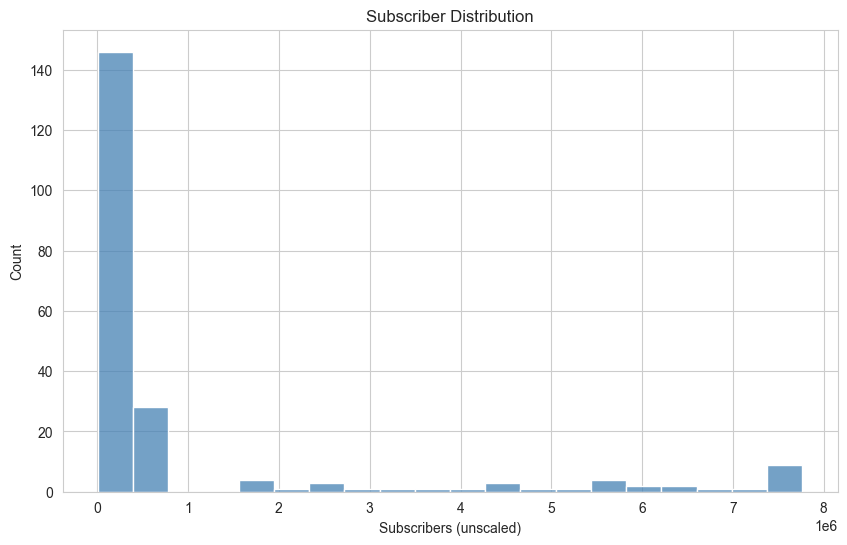

In [112]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df['subscribers'], bins=20, ax=ax, color='steelblue')

ax.set_xlabel('Subscribers (unscaled)')
ax.set_ylabel('Count')
ax.set_title('Subscriber Distribution')
plt.show()

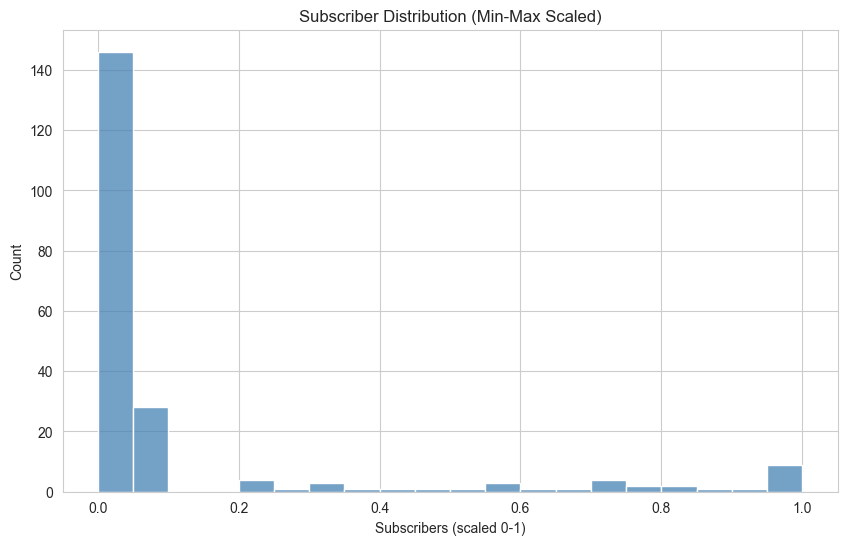

In [113]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df['subscribers_minmax'], bins=20, ax=ax, color='steelblue')

ax.set_xlabel('Subscribers (scaled 0-1)')
ax.set_ylabel('Count')
ax.set_title('Subscriber Distribution (Min-Max Scaled)')
plt.show()

Apply MinMax on duration seconds

In [114]:
df["duration_seconds_minmax"] = scaler.fit_transform(df[["duration_seconds"]])
df["duration_seconds_minmax"]

0      0.038991
1      0.121399
2      0.087607
3      0.082127
4      0.210201
         ...   
205    0.110370
206    0.394127
207    0.172193
208    0.245188
209    0.044752
Name: duration_seconds_minmax, Length: 210, dtype: float64

In [115]:
df["duration_seconds_minmax"].describe() # min is zero, max is one

count    210.000000
mean       0.171440
std        0.182455
min        0.000000
25%        0.057011
50%        0.114444
75%        0.210008
max        1.000000
Name: duration_seconds_minmax, dtype: float64

### Standard Scaler

In [116]:
standard_scaler = StandardScaler()

In [117]:
df["view_zscore"] = standard_scaler.fit_transform(df[["views"]])

In [118]:
df[["views", "view_zscore"]].describe() # min is negative, max is positive, values arranged around 0

,views,view_zscore
count,2.100000e+02,2.100000e+02
mean,5.485440e+05,2.537653e-17
std,1.223751e+06,1.002389e+00
min,1.412000e+03,-4.481625e-01
25%,1.080400e+04,-4.404694e-01
50%,6.597350e+04,-3.952794e-01
75%,3.108772e+05,-1.946757e-01
max,7.038551e+06,5.316044e+00


### Robust Scaler

In [119]:
robust_scaler = RobustScaler()

In [120]:
df["view_robust"] = robust_scaler.fit_transform(df[["views"]])

In [121]:
df[["views", "view_robust"]].describe()

,views,view_robust
count,2.100000e+02,210.000000
mean,5.485440e+05,1.608176
std,1.223751e+06,4.078175
min,1.412000e+03,-0.215152
25%,1.080400e+04,-0.183853
50%,6.597350e+04,0.000000
75%,3.108772e+05,0.816147
max,7.038551e+06,23.236251


Task: Apply all 3 on shares, and plot a histogram for one of them

In [122]:
df["shares_minmax"] = scaler.fit_transform(df[["shares"]])
df["shares_zscore"] = standard_scaler.fit_transform(df[["shares"]])
df["shares_robust"] = robust_scaler.fit_transform(df[["shares"]])

In [123]:
df[["shares", "shares_minmax", "shares_zscore", "shares_robust"]].describe()

,shares,shares_minmax,shares_zscore,shares_robust
count,210.000000,210.000000,210.000000,210.000000
mean,3947.052381,0.082128,0.000000,1.658617
std,8731.782974,0.181916,1.002389,4.009543
min,5.000000,0.000000,-0.452539,-0.151533
25%,65.500000,0.001260,-0.445594,-0.123752
50%,335.000000,0.006875,-0.414656,0.000000
75%,2243.250000,0.046631,-0.195593,0.876248
max,48004.000000,1.000000,5.057641,21.889106


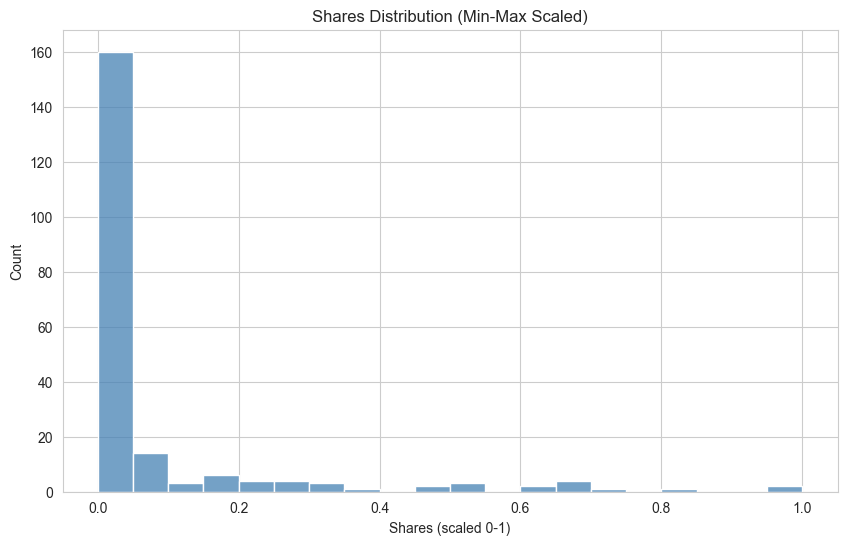

In [124]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df['shares_minmax'], bins=20, ax=ax, color='steelblue')

ax.set_xlabel('Shares (scaled 0-1)')
ax.set_ylabel('Count')
ax.set_title('Shares Distribution (Min-Max Scaled)')
plt.show()

### Log Transform

In [125]:
df["views_log"] = np.log1p(df["views"])

<Axes: xlabel='views_log', ylabel='Count'>

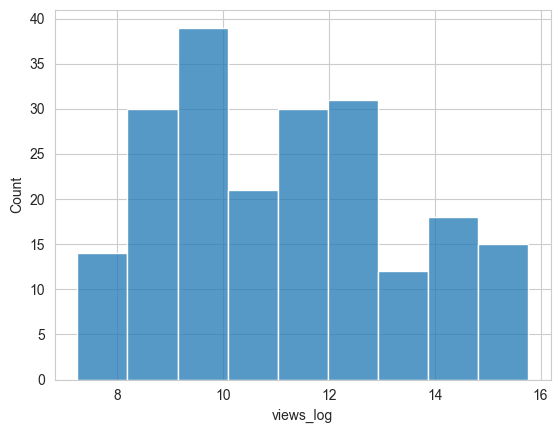

In [126]:
sns.histplot(df["views_log"])

<Axes: xlabel='views', ylabel='Count'>

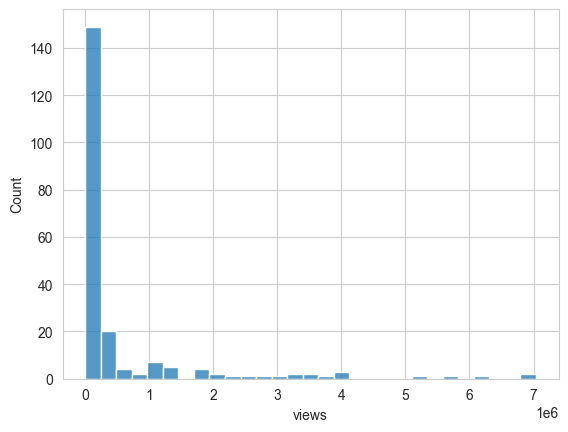

In [127]:
sns.histplot(df["views"])

In [128]:
df["watch_time_minutes_log"] = np.log1p(df["watch_time_minutes"])

<Axes: xlabel='watch_time_minutes_log', ylabel='Count'>

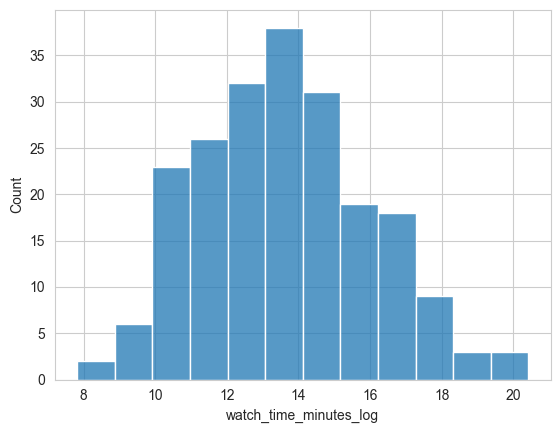

In [129]:
sns.histplot(df["watch_time_minutes_log"])

<Axes: xlabel='watch_time_minutes', ylabel='Count'>

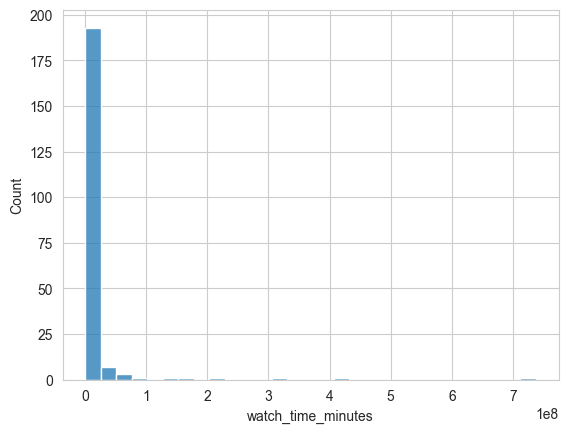

In [130]:
sns.histplot(df["watch_time_minutes"])

### Binning

In [146]:
# turn numerical values into categorical
bins = [0, 300, 2000, float("inf")]
labels = ["short", "medium", "long"]

df["duration_bin"] = pd.cut(df["duration_seconds"], bins=bins, labels=labels)

<Axes: xlabel='duration_bin', ylabel='count'>

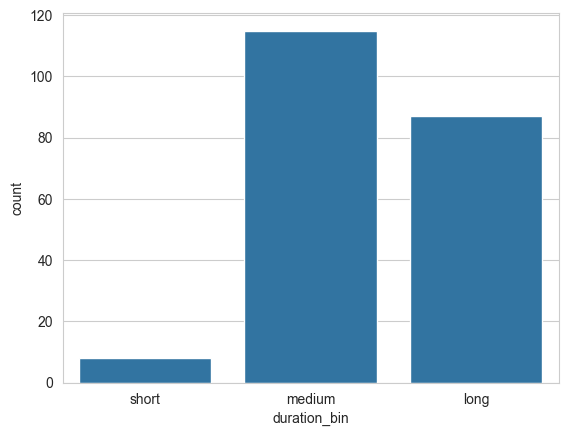

In [147]:
sns.countplot(data=df, x="duration_bin")

In [148]:
bins = [0, 500, 1000, 1500, 2000, float("inf")]
labels = ["niche", "trending", "viral", "meme", "vine level"]

df["shares_bin"] = pd.cut(df["shares"], bins=bins, labels=labels)

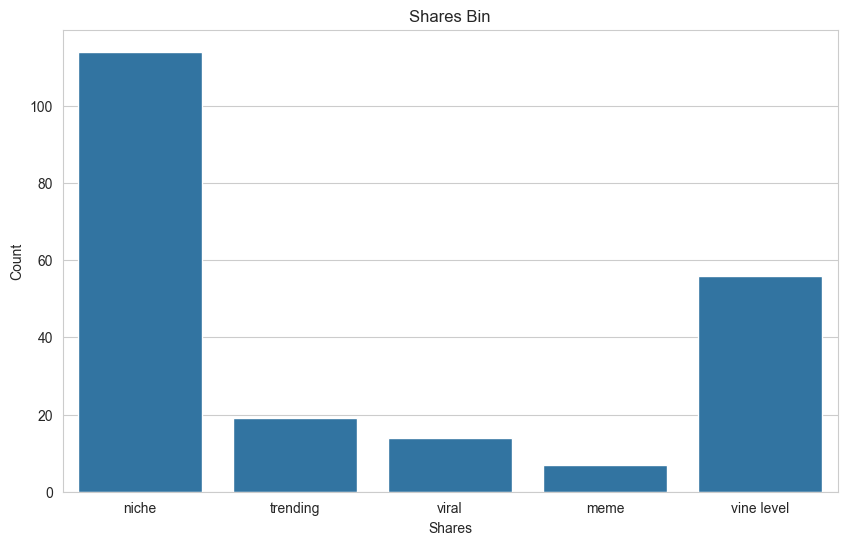

In [149]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(data=df, x="shares_bin")

ax.set_xlabel('Shares')
ax.set_ylabel('Count')
ax.set_title('Shares Bin')
plt.show()


### Ordinal Encoding

In [135]:
labels = df["channel_tier"].unique()
labels

<ArrowStringArray>
['Mid', 'Small', 'Large']
Length: 3, dtype: str

In [151]:
# category ordering is important, ['Mid', 'Small', 'Large'] = [1, 2, 3], so small comes first
encoder = OrdinalEncoder(categories=[["Small", "Mid", "Large"]])
df[["channel_tier_encoded"]] = encoder.fit_transform(df[["channel_tier"]]).astype(int)

In [137]:
df[["channel_tier_encoded"]].describe()

,channel_tier_encoded
count,210.000000
mean,0.714286
std,0.741320
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,2.000000


### One-Hot Encoding

In [153]:
# creating dummy variables, like isMusic, then 1 for true, 0 for false.
dummy_vars = pd.get_dummies(df["category"], prefix="is")

dummy_vars

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
205,False,True,False,False,False,False
206,False,False,False,False,True,False
207,False,False,True,False,False,False
208,True,False,False,False,False,False


In [155]:
df = pd.concat([df, dummy_vars], axis=1)

df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,...,uploaded_at,caps_count,duration_minutes,retention_rate,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,...,2024-01-07 00:05:00,3,12.016667,0.398058,False,False,False,True,False,False
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,...,2024-01-06 21:46:00,1,31.566667,0.535375,False,False,True,False,False,False
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,...,2024-01-08 18:39:00,0,23.550000,0.415428,False,False,True,False,False,False
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,...,2024-01-04 14:26:00,0,22.250000,0.483146,False,False,True,False,False,False
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,...,2024-01-08 04:25:00,4,52.633333,0.396453,False,False,False,True,False,False


### Date & Time Features

In [139]:
# simulate a full timestamp from existing day/hour columns
day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}
rng = np.random.default_rng(42)
base = pd.Timestamp("2024-01-01")

df["uploaded_at"] = [
    base
    + pd.offsets.Week(weekday=day_map[d])
    + pd.Timedelta(hours=int(h))
    + pd.Timedelta(minutes=int(rng.integers(0, 60)))
    for d, h in zip(df["upload_day"], df["upload_hour"])
]

In [156]:
df["uploaded_at"]

0     2024-01-07 00:05:00
1     2024-01-06 21:46:00
2     2024-01-08 18:39:00
3     2024-01-04 14:26:00
4     2024-01-08 04:25:00
              ...        
205   2024-01-05 13:15:00
206   2024-01-06 08:45:00
207   2024-01-07 20:58:00
208   2024-01-04 21:15:00
209   2024-01-05 10:46:00
Name: uploaded_at, Length: 210, dtype: datetime64[us]

In [140]:
df["uploaded_at"].dt.dayofweek

0      6
1      5
2      0
3      3
4      0
      ..
205    4
206    5
207    6
208    3
209    4
Name: uploaded_at, Length: 210, dtype: int32

### Text Analysis

In [157]:
df['title']

0      I tried EVERY transformers tool — the WINNER s...
1             What nobody tells you about AI image tools
2      What nobody tells you about machine learning p...
3                            Is Claude worth it in 2025?
4      URGENT: voice cloning AI is about to CHANGE FO...
                             ...                        
205    STOP using Python for AI WRONG (most people do...
206    I built a machine learning pipelines project —...
207                   What nobody tells you about Gemini
208    Why deep learning frameworks DESTROYED my work...
209                         GPT-4 is DEAD and here's WHY
Name: title, Length: 210, dtype: str

In [141]:
# count caps
df["caps_count"] = df["title"].apply(
    lambda t: sum(1 for w in t.split() if w.isupper())
)

In [158]:
df["caps_count"]

0      3
1      1
2      0
3      0
4      4
      ..
205    3
206    2
207    0
208    2
209    3
Name: caps_count, Length: 210, dtype: int64

In [160]:
def countCaps(t):
    sum = 0
    words = t.split()
    for word in words:
        if word.isupper():
            sum += 1
    return sum

In [162]:
# count caps
df["caps_count"] = df["title"].apply(
    countCaps
)
df["caps_count"]

0      3
1      1
2      0
3      0
4      4
      ..
205    3
206    2
207    0
208    2
209    3
Name: caps_count, Length: 210, dtype: int64

In [164]:
# count lowercase
df["lower_count"] = df["title"].apply(
    lambda t: sum(1 for w in t.split() if w.islower())
)
df["lower_count"]

0      6
1      6
2      7
3      3
4      5
      ..
205    6
206    9
207    4
208    9
209    3
Name: lower_count, Length: 210, dtype: int64

### TF-IDF

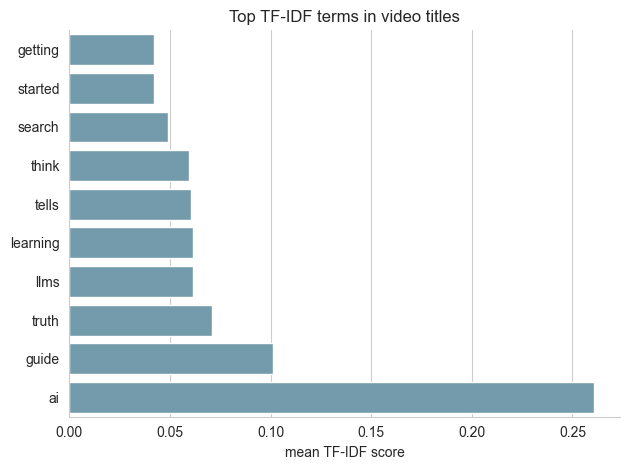

In [166]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df["title"])

terms = vectorizer.get_feature_names_out()
mean_scores = tfidf_matrix.toarray().mean(axis=0)

tfidf_df = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=True)

sns.barplot(data=tfidf_df,
            x="mean_tfidf",
            y="term",
            color="#6a9fb5")

plt.title("Top TF-IDF terms in video titles")
plt.xlabel("mean TF-IDF score")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

### Ratios and Interaction Features

In [167]:
df["duration_minutes"] = df["duration_seconds"] / 60

df["retention_rate"] = (
    df["watch_time_minutes"] /
    (df["views"] * df["duration_minutes"])
)

In [168]:
df[["duration_minutes", "retention_rate"]].describe()

,duration_minutes,retention_rate
count,210.000000,210.000000
mean,43.437857,0.416865
std,43.284308,0.110768
min,2.766667,0.134102
25%,16.291667,0.333084
50%,29.916667,0.424271
75%,52.587500,0.485783
max,240.000000,0.757328


### Interaction Features

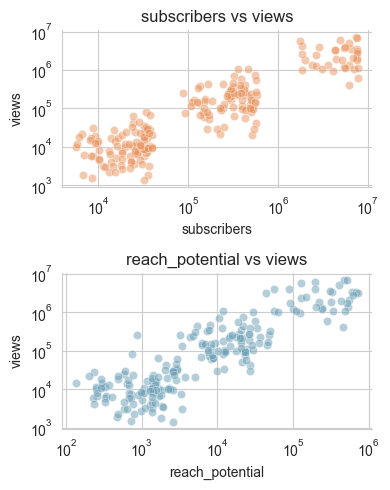

In [169]:
df["reach_potential"] = (
    df["subscribers"] * df["click_through_rate"]
)

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.scatterplot(data=df,
                x="subscribers",
                y="views",
                color="#e8925a",
                alpha=0.5,
                ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("subscribers vs views")

sns.scatterplot(data=df,
                x="reach_potential",
                y="views",
                color="#6a9fb5",
                alpha=0.5,
                ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("reach_potential vs views")

sns.despine()
plt.tight_layout()
plt.show()

### Multi Label Bins

In [170]:
from sklearn.preprocessing import MultiLabelBinarizer
import json

df["hashtags"] = df["hashtags"].apply(json.loads)

mlb = MultiLabelBinarizer()
hashtag_encoded = pd.DataFrame(
    mlb.fit_transform(df["hashtags"]),
    columns=mlb.classes_,
    index=df.index
)

result = pd.concat([df[["video_id"]], hashtag_encoded], axis=1)
print(result.head(4).to_string(index=False))

mlb = MultiLabelBinarizer()
hashtag_encoded = pd.DataFrame(
    mlb.fit_transform(df["hashtags"]),
    columns=mlb.classes_,
    index=df.index
)

result = pd.concat([df[["video_id"]], hashtag_encoded], axis=1)
print(result.head(4).to_string(index=False))

video_id  ai  chatgpt  comedy  datascience  deeplearning  explained  gaming  howto  llm  machinelearning  music  news  python  review  shorts  tech  trending  tutorial  viral  vlog
vid_0000   1        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         1         1      0     0
vid_0001   0        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         0         1      0     0
vid_0002   0        0       0            0             0          1       0      0    0                0      0     0       0       0       0     0         0         0      0     0
vid_0003   0        0       0            0             0          1       1      0    0                0      0     0       0       0       0     1         1         0      0     0
video_id  ai  chatgpt  comedy  datascience  deeplearning  explained  gaming  howto  llm  machin